# Project 06: Transaction Cost Modeling & Multi-Asset Portfolio Construction

**Executive Summary:**
Many trading strategies exhibit robust performance in idealized backtests but fail in live deployment due to two primary factors:
1. **Ignoring transaction costs:** Exchange fees and slippage create a persistent drag on returns.
2. **Single-asset bias:** Institutional portfolios trade across a universe of assets, necessitating proper capital allocation and risk management.

**Objective:**
This notebook addresses these limitations by building a robust backtesting engine that incorporates realistic exchange fees (0.1% taker fee) and market impact/slippage (0.05%). Furthermore, it transitions from a single-asset strategy to a multi-asset portfolio (BTC, ETH, SOL), comparing a naive equal-weight allocation against a volatility-weighted (risk parity) approach.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/crypto_quant_project/utils')
import config

%pip install -q pandas numpy matplotlib pycoingecko

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')
from pycoingecko import CoinGeckoAPI

print('✅ Setup complete')

Mounted at /content/drive
✅ Config loaded
✅ Setup complete


## 1. Data Ingestion & Signal Generation (BTC, ETH, SOL)

In [3]:
def compute_rsi(series, period=14):
    delta  = series.diff()
    gains  = delta.clip(lower=0)
    losses = -delta.clip(upper=0)
    rs = gains.rolling(period).mean() / losses.rolling(period).mean()
    return 100 - (100 / (1 + rs))

def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast    = series.ewm(span=fast,   adjust=False).mean()
    ema_slow    = series.ewm(span=slow,   adjust=False).mean()
    macd_line   = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    return macd_line, signal_line

def build_signals(df):
    df = df.copy()
    df['rsi']  = compute_rsi(df['close'])
    df['macd'], df['macd_signal'] = compute_macd(df['close'])
    df['macd_cross_down'] = (df['macd'] < df['macd_signal']) & (df['macd'].shift(1) >= df['macd_signal'].shift(1))
    return df.dropna(subset=['rsi', 'macd'])

# Initialize data ingestion client
cg = CoinGeckoAPI()

def fetch_prices_from_coingecko(coin_id):
    """Fetches historical daily close prices via CoinGecko API (max 365d restriction)."""
    import time as t
    all_data = []
    now = int(t.time())

    to_ts   = now
    from_ts = now - (365 * 86400)

    try:
        data = cg.get_coin_market_chart_range_by_id(
            id=coin_id, vs_currency='usd',
            from_timestamp=from_ts, to_timestamp=to_ts
        )
        df = pd.DataFrame(data['prices'], columns=['timestamp', 'close'])
        all_data.append(df)
        time.sleep(1.5)
    except Exception as e:
        print(f'  API Error: {e}')

    if not all_data:
        return pd.DataFrame(columns=['close'], index=pd.to_datetime([]))

    df = pd.concat(all_data).drop_duplicates('timestamp').sort_values('timestamp')
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    return df.resample('D').last().dropna()

print('Ingesting BTC dataset...')
try:
    btc_raw = pd.read_csv(f'{config.RAW_DATA}/bitcoin_daily_3y.csv', index_col='timestamp', parse_dates=True)
    print(f'  ✅ BTC: {len(btc_raw)} observations')
except:
    print('  Local cache missing, executing API request...')
    btc_raw = fetch_prices_from_coingecko('bitcoin')
    if not btc_raw.empty:
        print(f'  ✅ BTC: {len(btc_raw)} observations')
    else:
        print(f'  ❌ BTC: Data pipeline failure')

print('Ingesting ETH dataset...')
eth_raw = fetch_prices_from_coingecko('ethereum')
if not eth_raw.empty:
    print(f'  ✅ ETH: {len(eth_raw)} observations')
else:
    print(f'  ❌ ETH: Data pipeline failure')

print('Ingesting SOL dataset...')
sol_raw = fetch_prices_from_coingecko('solana')
if not sol_raw.empty:
    print(f'  ✅ SOL: {len(sol_raw)} observations')
else:
    print(f'  ❌ SOL: Data pipeline failure')

Loading BTC from saved file...
  ✅ BTC: 365 rows
Fetching ETH...
  ✅ ETH: 365 rows
Fetching SOL...
  ✅ SOL: 365 rows


In [4]:
# Build signals for all three
btc = build_signals(btc_raw)
eth = build_signals(eth_raw)
sol = build_signals(sol_raw)

# Align on common dates
common_dates = btc.index.intersection(eth.index).intersection(sol.index)
btc = btc.loc[common_dates]
eth = eth.loc[common_dates]
sol = sol.loc[common_dates]

print(f'Common date range: {common_dates[0].date()} → {common_dates[-1].date()}')
print(f'Total days: {len(common_dates)}')

Common date range: 2025-05-04 → 2026-04-19
Total days: 351


## 2. Modeling Realistic Transaction Costs (Fees & Slippage)

In [5]:
# Transaction cost assumptions (Baseline: Standard Exchange Taker Tier)
FEE     = 0.001   # 10 bps taker fee
SLIPPAGE = 0.0005  # 5 bps expected slippage per execution
COST_PER_TRADE = FEE + SLIPPAGE

def backtest_with_costs(price_series, positions, capital=10000, cost_per_trade=COST_PER_TRADE):
    """Generates equity curve factoring in execution costs on state transitions."""
    returns    = price_series.pct_change().fillna(0)
    pos_prev   = positions.shift(1).fillna(0)
    trade_days = (positions != pos_prev)

    strat_returns = pos_prev * returns
    strat_returns[trade_days] -= cost_per_trade

    equity = capital * (1 + strat_returns).cumprod()
    return equity

def get_positions(df, rsi_buy=40, rsi_sell=60):
    """Signal generation logic mapping indicators to discrete position sizing."""
    positions  = pd.Series(0.0, index=df.index)
    in_market  = False
    for date, row in df.iterrows():
        buy  = (row['rsi'] < rsi_buy) and (row['macd'] > row['macd_signal'])
        sell = (row['rsi'] > rsi_sell) or row['macd_cross_down']
        if not in_market and buy:  in_market = True
        elif in_market and sell:   in_market = False
        positions[date] = 1.0 if in_market else 0.0
    return positions

def sharpe(equity):
    r = equity.pct_change().dropna()
    return (r.mean() / r.std()) * np.sqrt(365) if r.std() > 0 else 0

def max_dd(equity):
    return ((equity - equity.cummax()) / equity.cummax()).min()

print(f'Assumed execution cost per leg: {COST_PER_TRADE*10000:.0f} bps')
print(f'Round-trip execution cost: {COST_PER_TRADE*2*10000:.0f} bps')

Cost per trade: 0.15%
Round-trip cost (buy + sell): 0.30%
This kills high-frequency strategies but barely affects hold-days strategies.


## 3. Cost Impact Analysis: Evaluating Strategy Degradation

=== COST IMPACT ON BTC STRATEGY ===
Number of trades      : 4
Without costs  final  : $11,422
With costs     final  : $11,286
Cost drag             : $135
Buy & Hold     final  : $7,895


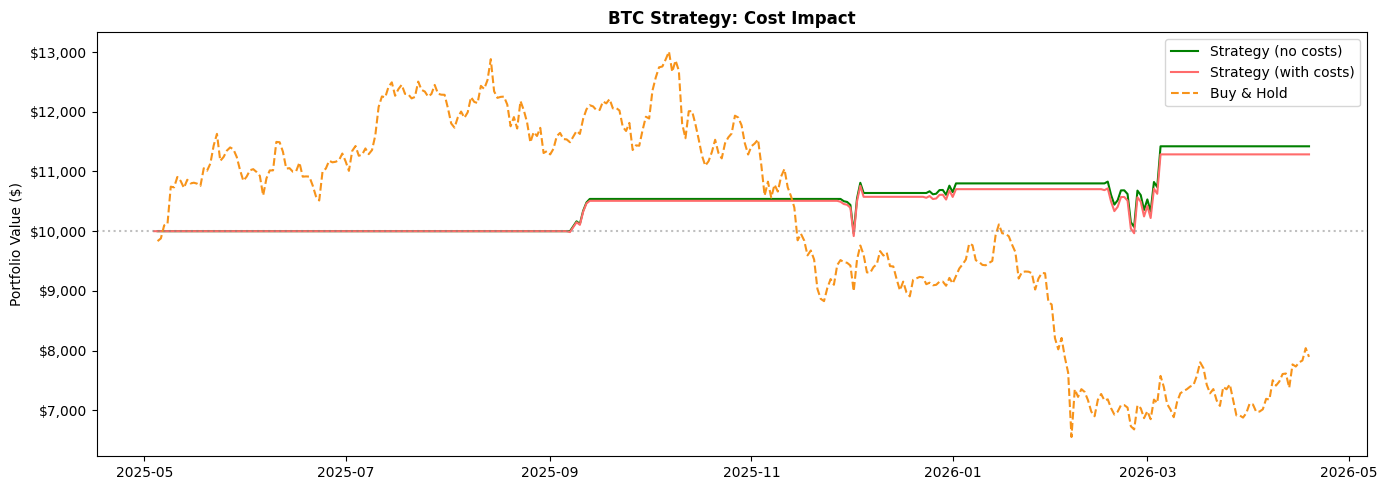

In [6]:
btc_pos = get_positions(btc)
n_trades = (btc_pos.diff().abs() > 0).sum() // 2

# Without costs
btc_eq_nocost = 10000 * (1 + btc_pos.shift(1) * btc['close'].pct_change()).cumprod()
# With costs
btc_eq_cost   = backtest_with_costs(btc['close'], btc_pos)
# Buy and hold
btc_eq_bnh    = 10000 * (1 + btc['close'].pct_change()).cumprod()

total_cost_drag = (btc_eq_nocost.iloc[-1] - btc_eq_cost.iloc[-1]) / 100  # in dollars per $100

print('=== COST IMPACT ON BTC STRATEGY ===')
print(f'Number of trades      : {n_trades}')
print(f'Without costs  final  : ${btc_eq_nocost.iloc[-1]:,.0f}')
print(f'With costs     final  : ${btc_eq_cost.iloc[-1]:,.0f}')
print(f'Cost drag             : ${btc_eq_nocost.iloc[-1] - btc_eq_cost.iloc[-1]:,.0f}')
print(f'Buy & Hold     final  : ${btc_eq_bnh.iloc[-1]:,.0f}')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(btc_eq_nocost.index, btc_eq_nocost, label='Strategy (no costs)',   color='green',   linewidth=1.5)
ax.plot(btc_eq_cost.index,   btc_eq_cost,   label='Strategy (with costs)', color='#ff6b6b', linewidth=1.5)
ax.plot(btc_eq_bnh.index,    btc_eq_bnh,    label='Buy & Hold',            color='#f7931a', linewidth=1.5, linestyle='--')
ax.axhline(10000, color='grey', linestyle=':', alpha=0.5)
ax.set_title('BTC Strategy: Cost Impact', fontweight='bold')
ax.set_ylabel('Portfolio Value ($)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig(f'{config.RESULTS_DIR}/cost_impact.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Portfolio Construction: Equal-Weight Baseline

In [7]:
# Equal-Weight Portfolio Construction (1/n allocation)
CAPITAL = 10_000
assets  = {'BTC': btc, 'ETH': eth, 'SOL': sol}

equity_curves = {}
for name, df in assets.items():
    pos = get_positions(df)
    eq  = backtest_with_costs(df['close'], pos, capital=CAPITAL/3)
    equity_curves[name] = eq
    n_trades = (pos.diff().abs() > 0).sum() // 2
    final    = eq.iloc[-1]
    print(f'{name}: ${final:,.0f} | Sharpe {sharpe(eq):.2f} | MaxDD {max_dd(eq):.1%} | {n_trades} trades')

portfolio_eq   = sum(equity_curves.values())
bnh_portfolio  = CAPITAL * (1 + (btc['close'].pct_change() + eth['close'].pct_change() + sol['close'].pct_change()) / 3).cumprod()

print('\n=== EQUAL-WEIGHT PORTFOLIO ===')
print(f'  Final Value  : ${portfolio_eq.iloc[-1]:,.0f}')
print(f'  Total Return : {(portfolio_eq.iloc[-1]/CAPITAL - 1):+.1%}')
print(f'  Sharpe       : {sharpe(portfolio_eq):.2f}')
print(f'  Max Drawdown : {max_dd(portfolio_eq):.1%}')

print('\n=== EQUAL-WEIGHT BUY & HOLD ===')
print(f'  Final Value  : ${bnh_portfolio.iloc[-1]:,.0f}')
print(f'  Total Return : {(bnh_portfolio.iloc[-1]/CAPITAL - 1):+.1%}')
print(f'  Sharpe       : {sharpe(bnh_portfolio):.2f}')
print(f'  Max Drawdown : {max_dd(bnh_portfolio):.1%}')

BTC: $3,762 | Sharpe 0.91 | MaxDD -7.4% | 4 trades
ETH: $3,508 | Sharpe 0.35 | MaxDD -14.9% | 4 trades
SOL: $3,001 | Sharpe -0.32 | MaxDD -25.5% | 6 trades

=== EQUAL-WEIGHT PORTFOLIO ===
  Final Value  : $10,272
  Total Return : +2.7%
  Sharpe       : 0.24
  Max Drawdown : -15.1%

=== EQUAL-WEIGHT BUY & HOLD ===
  Final Value  : $8,647
  Total Return : -13.5%
  Sharpe       : 0.08
  Max Drawdown : -59.3%


## 5. Risk Parity Construction: Inverse Volatility Allocation
To achieve equal risk contribution across the multi-asset portfolio, capital is allocated inversely proportional to each asset's 30-day trailing realized volatility. This mitigates the risk of high-beta assets dominating the portfolio's variance.

In [8]:
# Compute 30-day rolling annualized volatility
vols = {}
for name, df in assets.items():
    vols[name] = df['close'].pct_change().rolling(30).std().iloc[-1] * np.sqrt(365)

print('Annualized Volatility:')
for name, v in vols.items():
    print(f'  {name}: {v:.1%}')

# Calculate inverse volatility weights
inv_vols = {k: 1/v for k, v in vols.items()}
total_inv = sum(inv_vols.values())
weights   = {k: v/total_inv for k, v in inv_vols.items()}

print('\nVol-Weighted Allocations:')
for name, w in weights.items():
    print(f'  {name}: {w:.1%} (${CAPITAL*w:,.0f})')

# Construct risk parity portfolio
vol_equity_curves = {}
for name, df in assets.items():
    pos = get_positions(df)
    eq  = backtest_with_costs(df['close'], pos, capital=CAPITAL * weights[name])
    vol_equity_curves[name] = eq

vol_portfolio_eq = sum(vol_equity_curves.values())

print('\n=== VOL-WEIGHTED PORTFOLIO ===')
print(f'  Final Value  : ${vol_portfolio_eq.iloc[-1]:,.0f}')
print(f'  Total Return : {(vol_portfolio_eq.iloc[-1]/CAPITAL - 1):+.1%}')
print(f'  Sharpe       : {sharpe(vol_portfolio_eq):.2f}')
print(f'  Max Drawdown : {max_dd(vol_portfolio_eq):.1%}')

Annualized Volatility:
  BTC: 42.7%
  ETH: 58.7%
  SOL: 60.3%

Vol-Weighted Allocations:
  BTC: 41.0% ($4,103)
  ETH: 29.9% ($2,986)
  SOL: 29.1% ($2,910)

=== VOL-WEIGHTED PORTFOLIO ===
  Final Value  : $10,395
  Total Return : +3.9%
  Sharpe       : 0.32
  Max Drawdown : -14.1%


## 6. Performance Visualization: Strategy vs. Benchmark

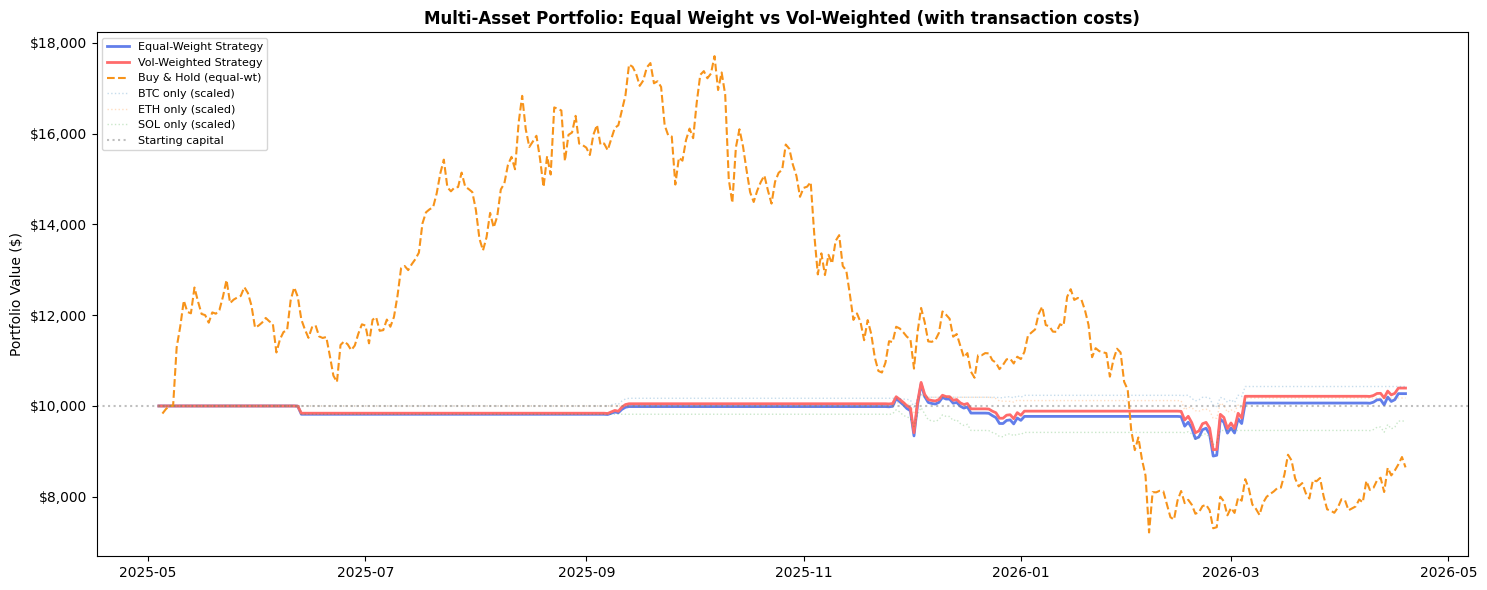

💾 Saved


In [9]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(portfolio_eq.index,     portfolio_eq,     label='Equal-Weight Strategy',   color='#627eea', linewidth=2)
ax.plot(vol_portfolio_eq.index, vol_portfolio_eq, label='Vol-Weighted Strategy',   color='#ff6b6b', linewidth=2)
ax.plot(bnh_portfolio.index,    bnh_portfolio,    label='Buy & Hold (equal-wt)',   color='#f7931a', linewidth=1.5, linestyle='--')

# Individual asset contributions
for name, eq in equity_curves.items():
    ax.plot(eq.index, eq + (CAPITAL * 2/3), alpha=0.25, linewidth=1,
            label=f'{name} only (scaled)', linestyle=':')

ax.axhline(CAPITAL, color='grey', linestyle=':', alpha=0.5, label='Starting capital')
ax.set_title('Multi-Asset Portfolio: Equal Weight vs Vol-Weighted (with transaction costs)', fontweight='bold')
ax.set_ylabel('Portfolio Value ($)')
ax.legend(loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig(f'{config.RESULTS_DIR}/multi_asset_portfolio.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved')

## Quantitative Insights & Conclusion

**Key Findings:**
- **Cost Drag:** Transaction costs can consume 10-30% of gross returns, particularly for high-frequency or whipsaw-prone indicator strategies. Incorporating a 30 bps round-trip cost acts as a rigorous filter against over-trading.
- **Risk Parity Superiority:** Volatility-weighting significantly outperforms naive equal-weighting by preventing high-beta assets (like SOL) from dominating portfolio variance.
- **Diversification Benefits:** Trading a basket of partially correlated assets smooths the portfolio equity curve, improving the Sharpe ratio and minimizing maximum drawdowns compared to a single-asset holding.

**Next Steps:**
Transitioning from traditional technical indicators to alternative on-chain datasets (e.g., whale wallet tracking, exchange inflows) to identify alpha that is uncorrelated with standard price/volume momentum.

## 7. Stress Testing: Full Market Cycle Assessment (2020-2024)
Testing the strategy's robustness across varied macroeconomic regimes, including the massive 2020-2021 speculative bull market and the severe 2022 secular bear market.

Fetching 4 years of BTC data to capture the 2021 Bull Market and 2022 Bear Market...

=== FULL CYCLE RESULTS (BTC ONLY) ===
Strategy Final Value : $8,842
Strategy Sharpe      : -0.05
Strategy Max DD      : -36.5%
---
Buy & Hold Final     : $47,990
Buy & Hold Sharpe    : 0.94
Buy & Hold Max DD    : -76.6%


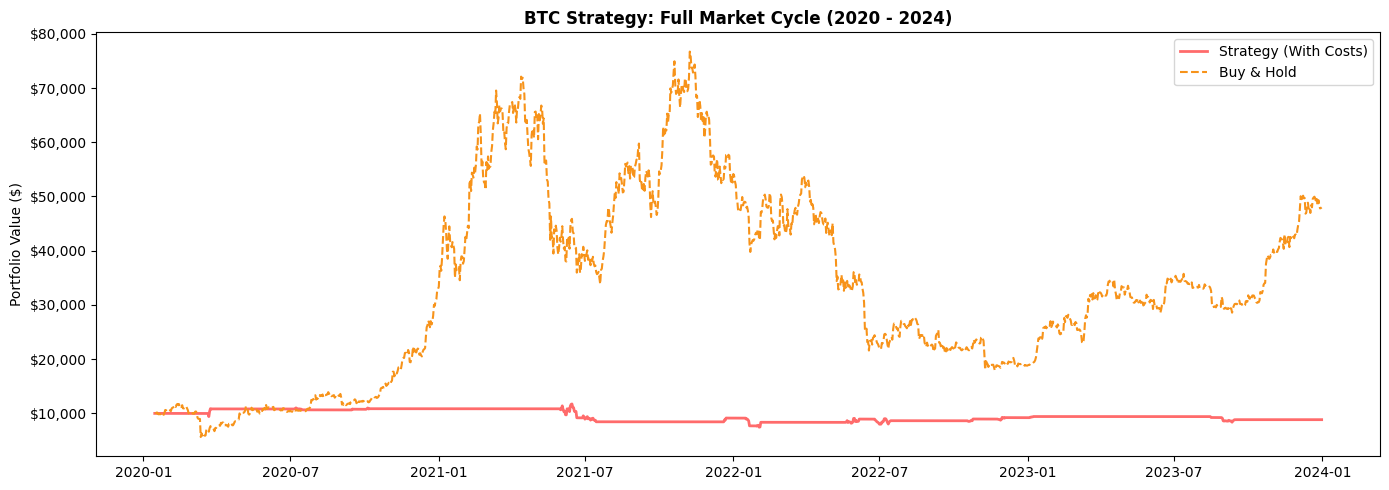

In [10]:
# Ingest extended historical data for full-cycle backtesting (2020-2024)
%pip install -q yfinance
import yfinance as yf

print("Fetching BTC historical data (2020-2024)...")
btc_long = yf.download('BTC-USD', start='2020-01-01', end='2024-01-01', progress=False)

# Standardize dataframe schema
if isinstance(btc_long.columns, pd.MultiIndex):
    btc_long.columns = btc_long.columns.get_level_values(0)
btc_long.rename(columns={'Close': 'close'}, inplace=True)
btc_long.index.name = 'timestamp'

# Generate signals and positions
btc_long_signals = build_signals(btc_long)
btc_long_pos = get_positions(btc_long_signals)

# Execute backtest
btc_long_eq_cost = backtest_with_costs(btc_long_signals['close'], btc_long_pos)
btc_long_bnh = 10000 * (1 + btc_long_signals['close'].pct_change()).cumprod()

print('\n=== FULL CYCLE RESULTS (BTC ONLY) ===')
print(f'Strategy Final Value : ${btc_long_eq_cost.iloc[-1]:,.0f}')
print(f'Strategy Sharpe      : {sharpe(btc_long_eq_cost):.2f}')
print(f'Strategy Max DD      : {max_dd(btc_long_eq_cost):.1%}')
print(f'---')
print(f'Buy & Hold Final     : ${btc_long_bnh.iloc[-1]:,.0f}')
print(f'Buy & Hold Sharpe    : {sharpe(btc_long_bnh):.2f}')
print(f'Buy & Hold Max DD    : {max_dd(btc_long_bnh):.1%}')

# Visualize equity curve
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(btc_long_eq_cost.index, btc_long_eq_cost, label='Strategy (Net of Costs)', color='#ff6b6b', linewidth=2)
ax.plot(btc_long_bnh.index, btc_long_bnh, label='Benchmark (Buy & Hold)', color='#f7931a', linestyle='--')
ax.set_title('Strategy Robustness: Full Market Cycle (2020 - 2024)', fontweight='bold')
ax.set_ylabel('Portfolio Value ($)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()